# Module 3 - Outlier Detection
## MedcoreCore Pharma | Demand Planning Intilligence

Objective : Detect and qualify demand outliers using Isolation Forest (unsupervised ML). Distinguish noise outliers (data entry errors) from business outliers (real demand events)

Why it matters : Including noise outliers in forecast calculations inflates error metrics and degrades model performance. In general, business outliers must be kept and explained.

Our stack : Python -> pandas, numpy, scikit learn(IsolationForest), matplotlib, sqlite

In [1]:
# Cell 1 : Import & data loading

import pandas as pd 
import numpy as numpy
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest 

# Database connection
DB_PATH = os.path.join("..", "data", "medcore.db")
conn = sqlite3.connect(DB_PATH)

# Load sql tables
df_demand = pd.read_sql("SELECT * FROM demand_history", conn)
df_products = pd.read_sql("SELECT * FROM product_master", conn)

# Standardize column names
df_products.columns = df_products.columns.str.lower()

# merge
df = pd.merge(df_demand, df_products, on="sku_id", how="left")
df["week"] = pd.to_datetime(df["week"])

print(f"Rows loaded : {len(df)}")
print(f"Columns : {list(df.columns)}")
print(f"\nOutlier type distribution :")
print(df["outlier_type"].value_counts())

Rows loaded : 7600
Columns : ['sku_id', 'week', 'actual_demand', 'stock_on_hand', 'outlier_type', 'week_number', 'family', 'market', 'unit_cost', 'has_bias', 'has_seasonality', 'has_bullwhip']

Outlier type distribution :
outlier_type
none        7365
business     158
noise         77
Name: count, dtype: int64


In [2]:
# Cell 2 : Isolation Forest
# We run the algorithm on each SKU independetly
# Each SKU has its own demand profile. Outliers must be detected relative to that SKU's baseline

# Step 1 - Prepare feautures for thel
# We use actual_demand and week_number as input feautures
# week_number helps the model understand seasonal patterns

results = []

for sku_id in df["sku_id"].unique():

    #filter data for this SKU
    sku_data = df[df["sku_id"] == sku_id].copy()

    # Features : actual demand + week number
    X = sku_data[["actual_demand", "week_number"]].values

    #step 2 - Train isolation Forest on this SKU
    model = IsolationForest(
        n_estimators = 100, # number of trees
        contamination = 0.03, # expected proportion of outliers (3%)
        random_state = 42
    )
    model.fit(X)

    # Step 3 - Predict
    # Returns 1 (normal) or -1 (outlier)
    predictions = model.predict(X)

    # Anmaly score - more negative = more anomalous
    scores = model.decision_function(X)

    # step 4 - Store results
    sku_data = sku_data.copy()
    sku_data["if_prediction"] = predictions
    sku_data["if_score"] = scores.round(4)
    sku_data["is_outlier_if"] = (predictions == -1).astype(int)

    results.append(sku_data)

#combine all SKUs
df_results = pd.concat(results, ignore_index=True)

print(f"Total rows : {len(df_results)}")
print(f"\nIsolation Forest detections :")
print(df_results["is_outlier_if"].value_counts())
print(f"\nDetected as outlier : {df_results['is_outlier_if'].sum()} rows ({df_results['is_outlier_if'].mean()*100:.1f}%)")

Total rows : 7600

Isolation Forest detections :
is_outlier_if
0    7350
1     250
Name: count, dtype: int64

Detected as outlier : 250 rows (3.3%)


In [3]:
# Cell 3 : Evaluation
# We compare Isolation forest detections vs our ground truth (outlier_type)
# This tells us how well the algorithm performed

# Step 1 - Create comparison flags
# Ground truth : any outlier (business or noise) = 1, none = 0
df_results["is_outlier_true"] = (df_results["outlier_type"] != "none").astype(int)

# Step 2 - Confusion matrix values
true_positive = ((df_results["is_outlier_if"] == 1) & (df_results["is_outlier_true"] == 1)).sum()
false_positive = ((df_results["is_outlier_if"] == 1) & (df_results["is_outlier_true"] == 0)).sum()
false_negative = ((df_results["is_outlier_if"] == 0) & (df_results["is_outlier_true"] == 1)).sum()
true_negative = ((df_results["is_outlier_if"] == 0) & (df_results["is_outlier_true"] == 0)).sum()

# Step 3 - Metrics
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
f1_score = 2* (precision * recall) / (precision + recall)

print(" Isolation Forest Performance ")
print(f"\nTrue Positives (correctly detected outliers) : {true_positive}")
print(f"False Positives (normal flagged as outlier) : {false_positive}")
print(f"False Negatives (outlier missed)  : {false_negative}")
print(f"True Negatives (correctly identified normal) : {true_negative}")
print(f"\nPrecision : {precision:.1%}")
print(f"Recall : {recall:.1%}")
print(f"F1 Score : {f1_score:.1%}")

#Step 4 - Breakdwn by outlier type
print(f"\nDetection by outlier type :")
for outlier_type in ["business","noise"]:
    subset = df_results[df_results["outlier_type"] == outlier_type]
    detected = subset["is_outlier_if"].sum()
    total = len(subset)
    print(f" {outlier_type} : {detected}/{total} detected ({detected/total*100:.1f}%)")




 Isolation Forest Performance 

True Positives (correctly detected outliers) : 199
False Positives (normal flagged as outlier) : 51
False Negatives (outlier missed)  : 36
True Negatives (correctly identified normal) : 7314

Precision : 79.6%
Recall : 84.7%
F1 Score : 82.1%

Detection by outlier type :
 business : 122/158 detected (77.2%)
 noise : 77/77 detected (100.0%)


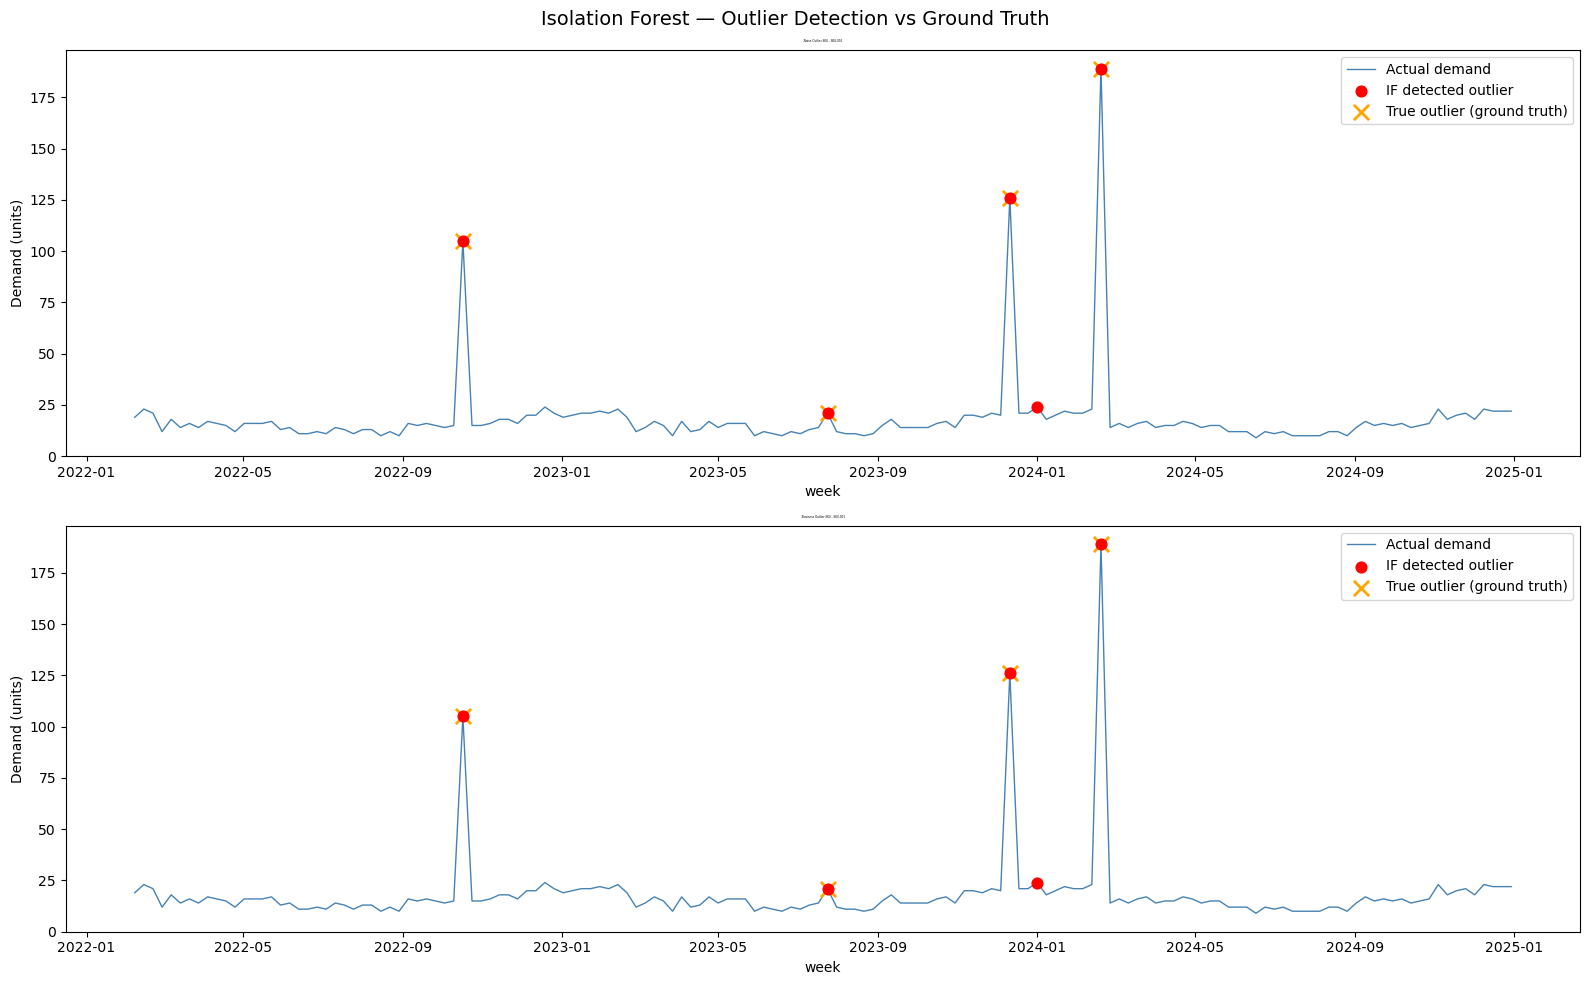

In [8]:
# Cell 4 : Visualization
# We plot deteccted outliers vs ground truth for 2 SKUs. One with noise outliers, one with business outliers

fig, axes = plt.subplots(2, 1, figsize=(16,10))

# pick one SKU with noise outliers and one with business outliers
sku_noise = df_results[df_results["outlier_type"] == "noise"]["sku_id"].iloc[0]
sku_business = df_results[df_results["outlier_type"] == "business"]["sku_id"].iloc[0]

for idx, (sku, title) in enumerate([(sku_noise, "Noise Outlier SKU"), (sku_business,"Business Outlier SKU")]):

    sku_data = df_results[df_results["sku_id"] == sku].copy()

    ax = axes[idx]

    # plot base demand
    ax.plot(sku_data["week"], sku_data["actual_demand"],
            color="steelblue", linewidth=1, label="Actual demand", zorder=1)
                       
    #plot IF detections
    if_outliers = sku_data[sku_data["is_outlier_if"] == 1]
    ax.scatter(if_outliers["week"], if_outliers["actual_demand"],
               color="red", s=60, zorder=3, label="IF detected outlier")
    
    #plot ground truth
    true_outliers = sku_data[sku_data["is_outlier_true"] == 1]
    ax.scatter(true_outliers["week"], true_outliers["actual_demand"],
               color="orange", s=120, marker="x", linewidths=2,
               zorder=2, label="True outlier (ground truth)")
               
    ax.set_title(f";{title} - {sku}", fontsize = 2)
    ax.set_xlabel("week")
    ax.set_ylabel("Demand (units)")
    
    ax.legend()
    
plt.suptitle("Isolation Forest — Outlier Detection vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()